# Breast Cancer Dataset Analysis

## Introduction

This project analyzes the Breast Cancer Wisconsin dataset to explore patterns that distinguish benign and malignant tumors.

The analysis focuses on:
- dataset structure and class distribution
- feature ranges and distributions
- relationships between tumor characteristics and malignancy
- comparison of benign and malignant tumors
- logistic regression as a baseline classification model
- ROC curve, precision, recall, and error analysis

The goal is not only to describe the data, but also to identify which features are most useful for separating tumor classes.

“How do small vs large tumors differ in malignancy rate?”

In [1]:
# ==========================================================
# Breast Cancer Wisconsin Dataset Analysis
# “How do small vs large tumors differ in malignancy rate?”
# ==========================================================

# If needed, install packages:
# !pip install pandas numpy matplotlib seaborn scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_score,
    recall_score
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
# Load dataset
data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df["diagnosis"] = data.target

# In sklearn:
# 0 = malignant
# 1 = benign
# Convert to labels for readability
df["diagnosis_label"] = df["diagnosis"].map({0: "M", 1: "B"})

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis,diagnosis_label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,M


## 1. Data Overview

This section answers the following basic questions:
- How many observations are in the dataset?
- What is the distribution of benign vs malignant tumors?
- What percentage does each class represent?
- What features are included in the dataset?


In [3]:
# Number of observations and features
n_rows, n_cols = df.shape
print(f"Number of observations: {n_rows}")
print(f"Number of columns: {n_cols}")
print(f"Number of feature columns (excluding target labels): {len(data.feature_names)}")

Number of observations: 569
Number of columns: 32
Number of feature columns (excluding target labels): 30


In [4]:
# Class distribution
class_counts = df["diagnosis_label"].value_counts()
class_percentages = df["diagnosis_label"].value_counts(normalize=True) * 100

print("Class counts:")
print(class_counts)
print("\nClass percentages:")
print(class_percentages.round(2))

Class counts:
diagnosis_label
B    357
M    212
Name: count, dtype: int64

Class percentages:
diagnosis_label
B    62.74
M    37.26
Name: proportion, dtype: float64


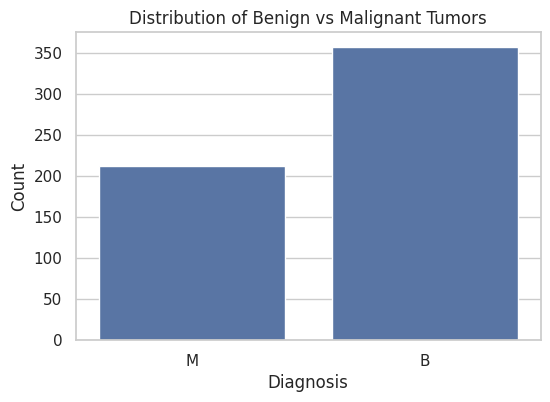

In [5]:
# Visualize class distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="diagnosis_label")
plt.title("Distribution of Benign vs Malignant Tumors")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()

In [6]:
# Feature names
feature_list = list(data.feature_names)
print("Features included in the dataset:")
for feature in feature_list:
    print("-", feature)

Features included in the dataset:
- mean radius
- mean texture
- mean perimeter
- mean area
- mean smoothness
- mean compactness
- mean concavity
- mean concave points
- mean symmetry
- mean fractal dimension
- radius error
- texture error
- perimeter error
- area error
- smoothness error
- compactness error
- concavity error
- concave points error
- symmetry error
- fractal dimension error
- worst radius
- worst texture
- worst perimeter
- worst area
- worst smoothness
- worst compactness
- worst concavity
- worst concave points
- worst symmetry
- worst fractal dimension


### Interpretation

The dataset contains 569 observations. The target variable distinguishes between malignant (M) and benign (B) tumors.

Understanding the class balance is important because classification metrics such as accuracy can be misleading if one class dominates the dataset.

## 2. Data Quality and Initial Inspection

This section addresses:
- Are there any missing values or anomalies?
- Which features have the largest ranges?

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [9]:
# Missing values
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

,0


In [10]:
# Summary statistics
df.describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


In [11]:
# Feature ranges
feature_ranges = df[data.feature_names].max() - df[data.feature_names].min()
feature_ranges_sorted = feature_ranges.sort_values(ascending=False)

feature_ranges_sorted.head(10)

,0
worst area,4068.800
mean area,2357.500
area error,535.398
worst perimeter,200.790
mean perimeter,144.710
worst texture,37.520
mean texture,29.570
worst radius,28.110
perimeter error,21.223
mean radius,21.129


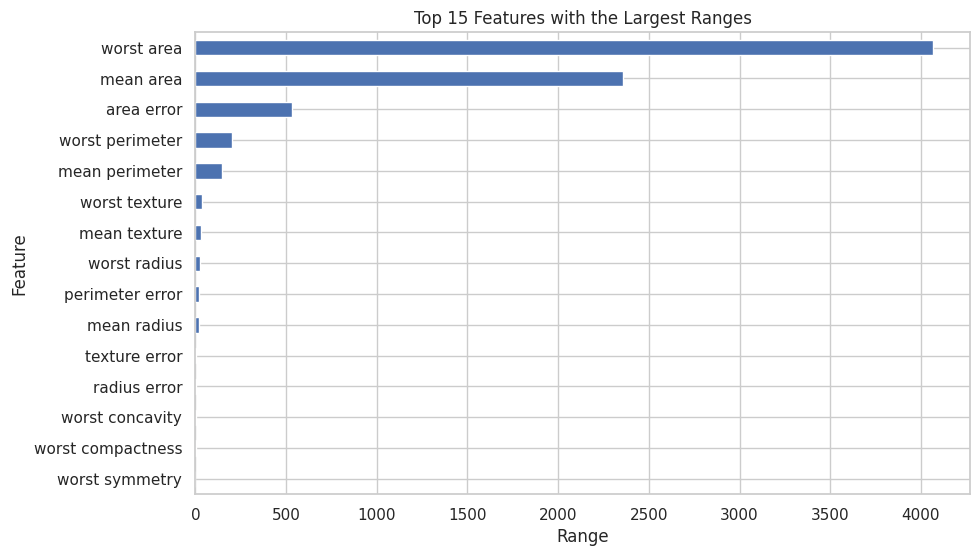

In [12]:
plt.figure(figsize=(10, 6))
feature_ranges_sorted.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 Features with the Largest Ranges")
plt.xlabel("Range")
plt.ylabel("Feature")
plt.show()

### Interpretation

The dataset does not contain missing values, which simplifies preprocessing.

Feature ranges differ substantially. Variables such as worst area, mean area, and area error usually show much larger numeric spreads than variables like smoothness or fractal dimension. This suggests that scaling will be necessary before training logistic regression.

## 3. Distribution of Key Features

This section examines:
- How are key features like radius, area, and texture distributed?

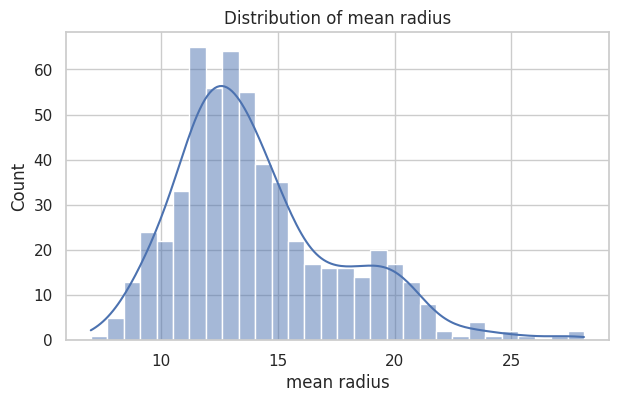

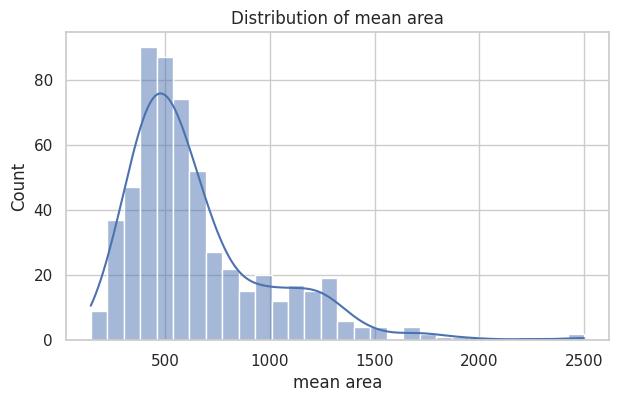

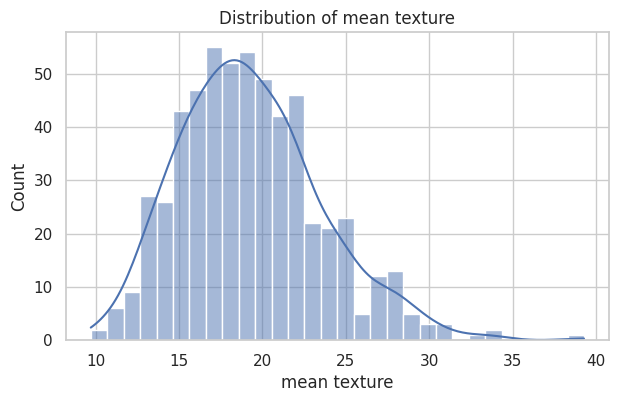

In [13]:
key_features = ["mean radius", "mean area", "mean texture"]

for feature in key_features:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=df, x=feature, kde=True, bins=30)
    plt.title(f"Distribution of {feature}")
    plt.show()

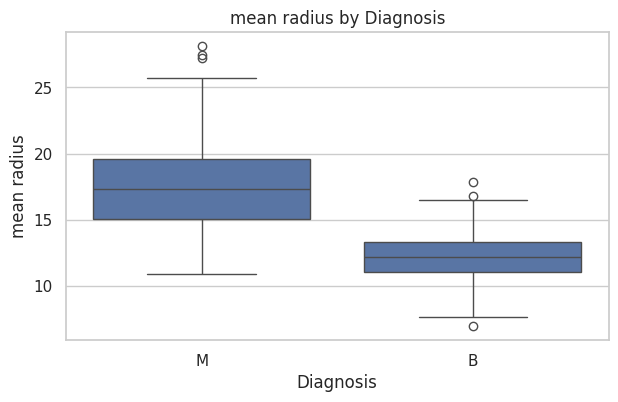

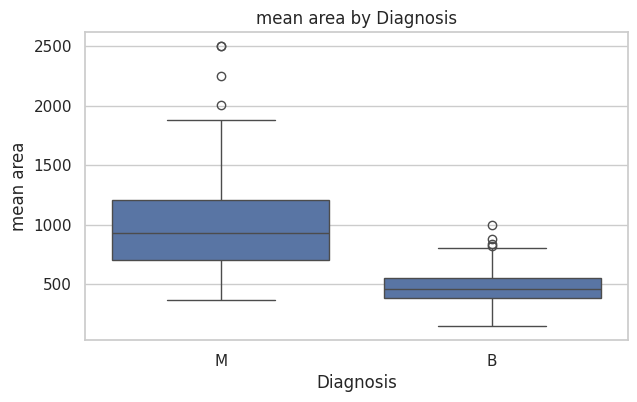

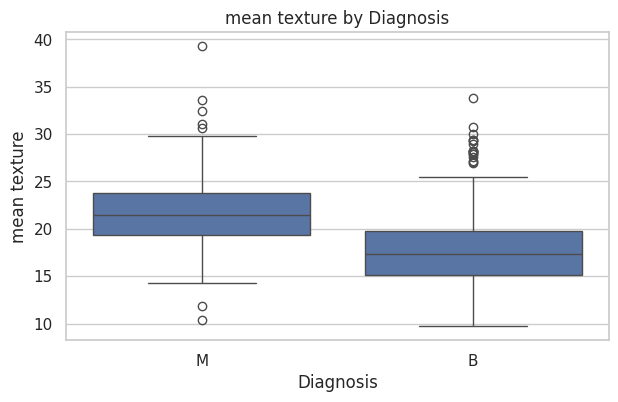

In [14]:
for feature in key_features:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x="diagnosis_label", y=feature)
    plt.title(f"{feature} by Diagnosis")
    plt.xlabel("Diagnosis")
    plt.ylabel(feature)
    plt.show()

### Interpretation

The distributions of radius, area, and texture show substantial variation across tumors.

Comparing boxplots by diagnosis provides an initial indication that malignant tumors tend to have larger radius and area values than benign tumors. Texture may also differ, although usually with more overlap between classes.

## 4. Feature-Based Group Analysis

This section addresses:
- How do small vs large tumors differ in malignancy rate?
- How does malignancy change with increasing radius?
- Are there thresholds where tumors become more likely malignant?
- How do low vs high texture values relate to tumor type?
- How do combinations such as high radius + high area behave?

In [15]:
# Create a binary malignant variable for easier interpretation
# 1 = malignant, 0 = benign
df["malignant"] = df["diagnosis_label"].map({"M": 1, "B": 0})

# Define small vs large tumors using median mean radius
radius_median = df["mean radius"].median()
df["tumor_size_group"] = np.where(df["mean radius"] < radius_median, "Small", "Large")

# Malignancy rate by size group
malignancy_by_size = df.groupby("tumor_size_group")["malignant"].mean() * 100
malignancy_by_size

,malignant
tumor_size_group,
Large,68.421053
Small,5.985915


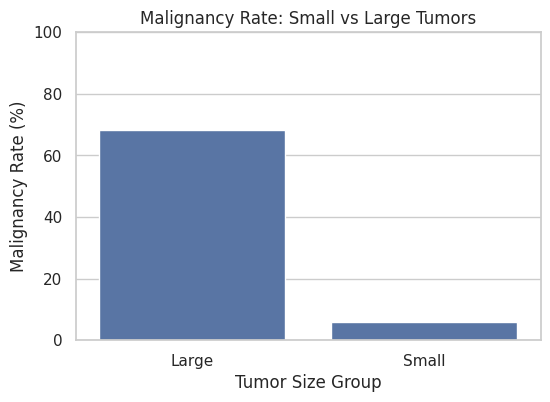

In [17]:
plt.figure(figsize=(6, 4))
sns.barplot(x=malignancy_by_size.index, y=malignancy_by_size.values)
plt.title("Malignancy Rate: Small vs Large Tumors")
plt.xlabel("Tumor Size Group")
plt.ylabel("Malignancy Rate (%)")
plt.ylim(0, 100)
plt.show()

### Interpretation

To compare small and large tumors, the dataset was split at the median of mean radius.

This allows us to calculate the malignancy rate within each group. If the large-tumor group has a much higher malignancy rate, this suggests that tumor size is strongly associated with malignancy.

In [18]:
# Malignancy by radius quartiles
df["radius_quartile"] = pd.qcut(df["mean radius"], q=4, labels=["Q1", "Q2", "Q3", "Q4"])
malignancy_by_quartile = df.groupby("radius_quartile", observed=False)["malignant"].mean() * 100
malignancy_by_quartile

,malignant
radius_quartile,
Q1,2.097902
Q2,9.859155
Q3,41.549296
Q4,95.774648


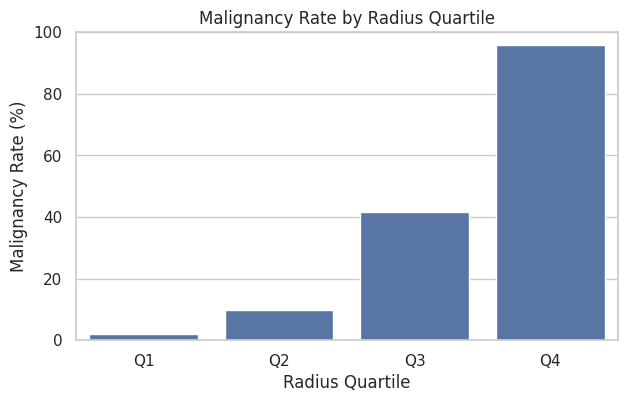

In [19]:
plt.figure(figsize=(7, 4))
sns.barplot(x=malignancy_by_quartile.index, y=malignancy_by_quartile.values)
plt.title("Malignancy Rate by Radius Quartile")
plt.xlabel("Radius Quartile")
plt.ylabel("Malignancy Rate (%)")
plt.ylim(0, 100)
plt.show()

### Interpretation

Grouping tumors into radius quartiles provides a more detailed view than a simple small/large split.

If malignancy increases steadily from Q1 to Q4, this suggests a strong monotonic relationship between radius and tumor type. Such a pattern may also indicate that certain radius thresholds are clinically or analytically meaningful.

In [20]:
# Low vs high texture using median split
texture_median = df["mean texture"].median()
df["texture_group"] = np.where(df["mean texture"] < texture_median, "Low Texture", "High Texture")

texture_malignancy = df.groupby("texture_group")["malignant"].mean() * 100
texture_malignancy

,malignant
texture_group,
High Texture,58.245614
Low Texture,16.197183


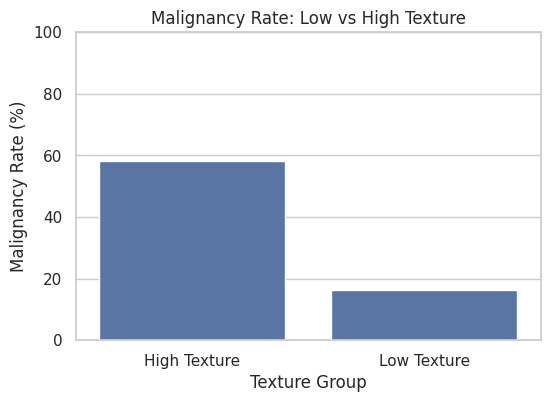

In [21]:
plt.figure(figsize=(6, 4))
sns.barplot(x=texture_malignancy.index, y=texture_malignancy.values)
plt.title("Malignancy Rate: Low vs High Texture")
plt.xlabel("Texture Group")
plt.ylabel("Malignancy Rate (%)")
plt.ylim(0, 100)
plt.show()

In [22]:
# Combination analysis: high radius + high area
radius_high = df["mean radius"] >= df["mean radius"].median()
area_high = df["mean area"] >= df["mean area"].median()

conditions = [
    (~radius_high) & (~area_high),
    (~radius_high) & (area_high),
    (radius_high) & (~area_high),
    (radius_high) & (area_high)
]

labels = [
    "Low Radius + Low Area",
    "Low Radius + High Area",
    "High Radius + Low Area",
    "High Radius + High Area"
]

df["radius_area_group"] = np.select(conditions, labels, default="Other")

combo_malignancy = df.groupby("radius_area_group")["malignant"].mean() * 100
combo_malignancy = combo_malignancy.reindex(labels)
combo_malignancy

,malignant
radius_area_group,
Low Radius + Low Area,6.007067
Low Radius + High Area,0.000000
High Radius + Low Area,0.000000
High Radius + High Area,68.661972


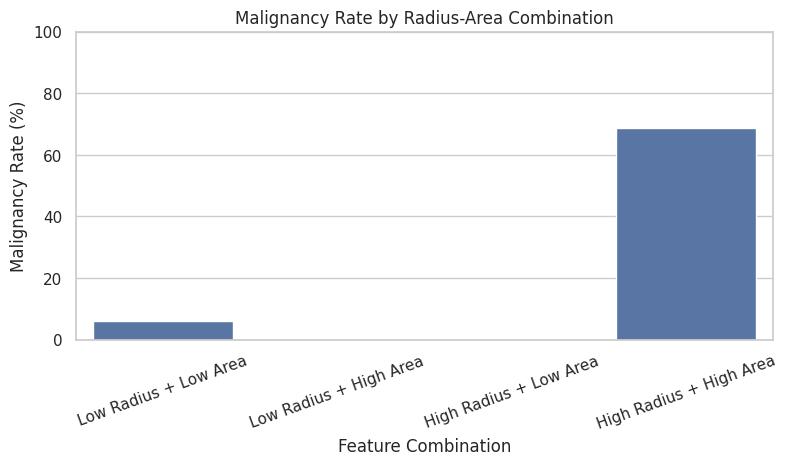

In [23]:
plt.figure(figsize=(9, 4))
sns.barplot(x=combo_malignancy.index, y=combo_malignancy.values)
plt.title("Malignancy Rate by Radius-Area Combination")
plt.xlabel("Feature Combination")
plt.ylabel("Malignancy Rate (%)")
plt.xticks(rotation=20)
plt.ylim(0, 100)
plt.show()

### Interpretation

Feature combinations can separate tumors more clearly than a single variable alone.

For example, tumors with both high radius and high area are expected to show a higher malignancy rate than tumors with low values on both features. This supports the idea that combinations of geometric features improve class separation.

## 5. Comparative Analysis

This section addresses:
- Which features differ most between benign and malignant tumors?
- Which features are strongly correlated?
- Are there redundant features?
- Which feature combinations give the best separation?
- Are there outliers affecting the analysis?

In [24]:
# Compare means by diagnosis
feature_means_by_class = df.groupby("diagnosis_label")[data.feature_names].mean().T
feature_means_by_class["absolute_difference"] = (
    feature_means_by_class["M"] - feature_means_by_class["B"]
).abs()

feature_means_by_class.sort_values("absolute_difference", ascending=False).head(15)

diagnosis_label,B,M,absolute_difference
worst area,558.899440,1422.286321,863.386881
mean area,462.790196,978.376415,515.586219
worst perimeter,87.005938,141.370330,54.364392
area error,21.135148,72.672406,51.537257
mean perimeter,78.075406,115.365377,37.289971
worst radius,13.379801,21.134811,7.755010
worst texture,23.515070,29.318208,5.803138
mean radius,12.146524,17.462830,5.316306
mean texture,17.914762,21.604906,3.690144
perimeter error,2.000321,4.323929,2.323608


In [25]:
# Compare means by diagnosis
feature_means_by_class = df.groupby("diagnosis_label")[data.feature_names].mean().T
feature_means_by_class["absolute_difference"] = (
    feature_means_by_class["M"] - feature_means_by_class["B"]
).abs()

feature_means_by_class.sort_values("absolute_difference", ascending=False).head(15)

diagnosis_label,B,M,absolute_difference
worst area,558.899440,1422.286321,863.386881
mean area,462.790196,978.376415,515.586219
worst perimeter,87.005938,141.370330,54.364392
area error,21.135148,72.672406,51.537257
mean perimeter,78.075406,115.365377,37.289971
worst radius,13.379801,21.134811,7.755010
worst texture,23.515070,29.318208,5.803138
mean radius,12.146524,17.462830,5.316306
mean texture,17.914762,21.604906,3.690144
perimeter error,2.000321,4.323929,2.323608


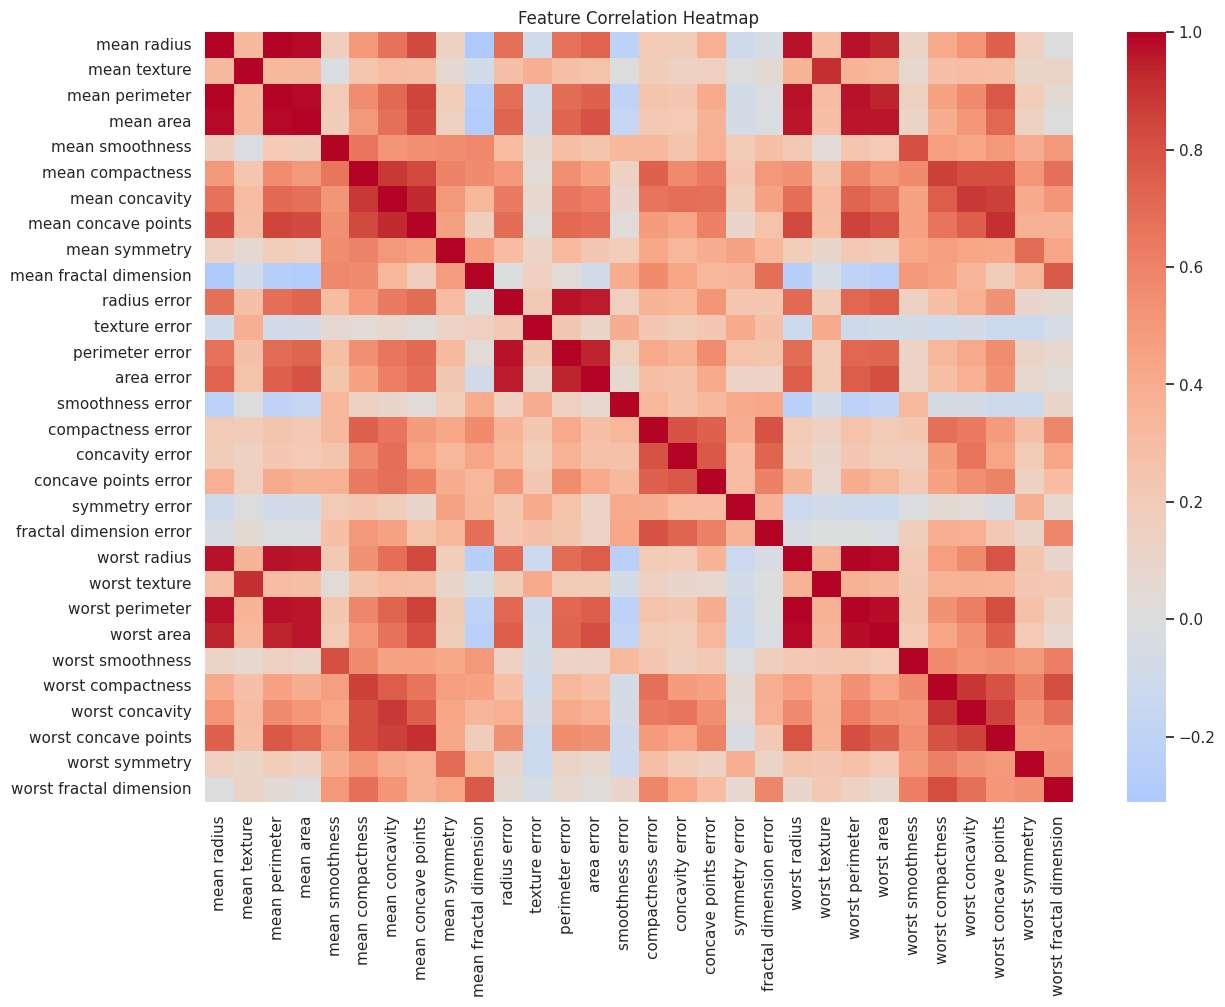

In [26]:
# Correlation matrix
corr_matrix = df[data.feature_names].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

In [27]:
# Strong correlations
corr_pairs = corr_matrix.abs().unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1]  # remove self-correlation

strong_corr = corr_pairs[corr_pairs > 0.90].drop_duplicates()
strong_corr.head(20)

mean perimeter       mean radius        0.997855
worst radius         worst perimeter    0.993708
mean radius          mean area          0.987357
mean area            mean perimeter     0.986507
worst area           worst radius       0.984015
                     worst perimeter    0.977578
radius error         perimeter error    0.972794
worst perimeter      mean perimeter     0.970387
mean radius          worst radius       0.969539
worst radius         mean perimeter     0.969476
worst perimeter      mean radius        0.965137
mean area            worst radius       0.962746
                     worst area         0.959213
worst perimeter      mean area          0.959120
radius error         area error         0.951830
worst area           mean perimeter     0.941550
                     mean radius        0.941082
area error           perimeter error    0.937655
mean concave points  mean concavity     0.921391
worst texture        mean texture       0.912045
dtype: float64

### Interpretation

Many radius-, perimeter-, and area-related variables are strongly correlated. This indicates redundancy among geometric measurements.

Highly correlated features can be informative for exploratory analysis, but they may also reduce interpretability if too many similar predictors are included in a model.

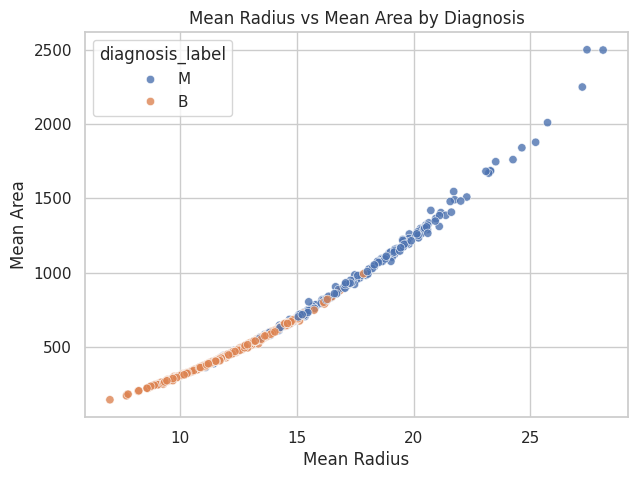

In [28]:
# Scatterplots for separation
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df,
    x="mean radius",
    y="mean area",
    hue="diagnosis_label",
    alpha=0.8
)
plt.title("Mean Radius vs Mean Area by Diagnosis")
plt.xlabel("Mean Radius")
plt.ylabel("Mean Area")
plt.show()

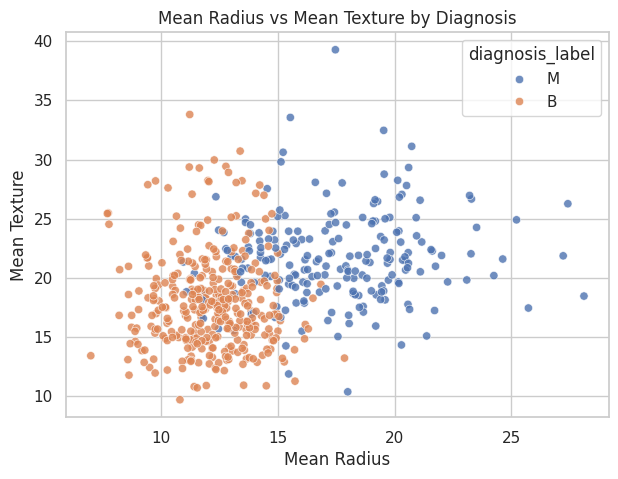

In [29]:
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df,
    x="mean radius",
    y="mean texture",
    hue="diagnosis_label",
    alpha=0.8
)
plt.title("Mean Radius vs Mean Texture by Diagnosis")
plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")
plt.show()

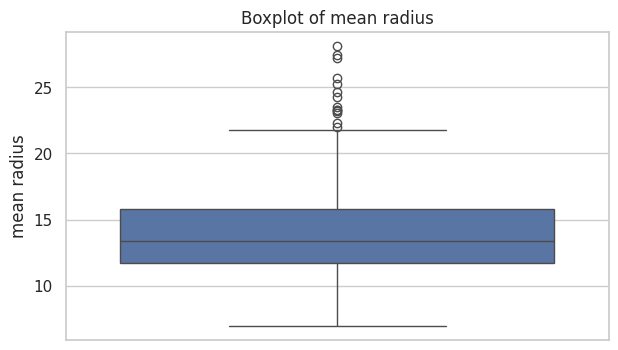

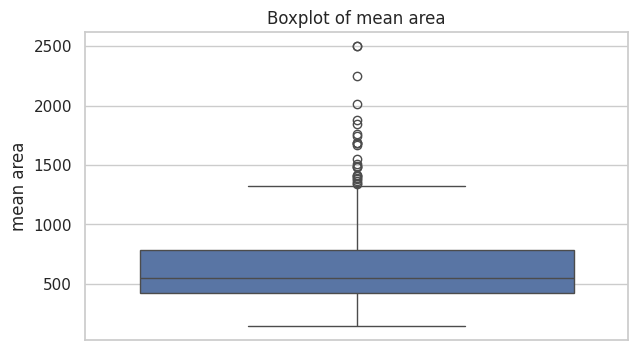

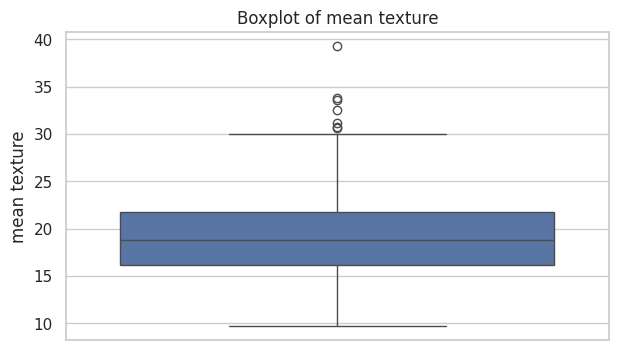

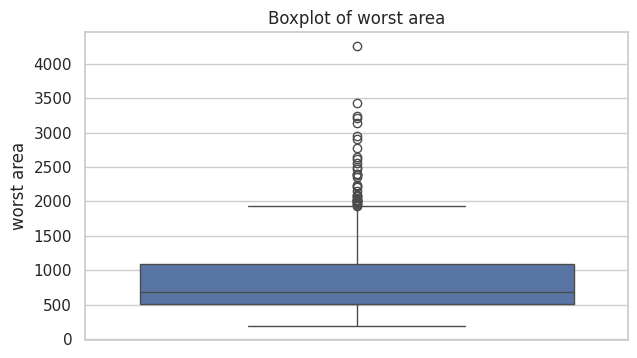

In [30]:
# Outlier inspection with boxplots
selected_features = ["mean radius", "mean area", "mean texture", "worst area"]

for feature in selected_features:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, y=feature)
    plt.title(f"Boxplot of {feature}")
    plt.show()

### Interpretation

Scatterplots suggest that some feature combinations separate benign and malignant tumors more clearly than individual features alone.

Boxplots also indicate the presence of outliers in several variables. These observations may reflect clinically extreme tumors rather than data errors, so they should be interpreted carefully rather than automatically removed.

## 6. Machine Learning: Logistic Regression

This section addresses:
- How well can a model classify tumors?
- What accuracy does logistic regression achieve?
- What does the ROC curve look like?
- Which features have the strongest predictive power?
- How does precision vs recall behave?
- What errors occur (false positives vs false negatives)?

In [31]:
# Prepare data
X = df[data.feature_names]
y = df["malignant"]  # 1 = malignant, 0 = benign

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression
model = LogisticRegression(max_iter=10000, random_state=42)
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

In [32]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"ROC AUC:   {auc:.4f}")

Accuracy:  0.9649
Precision: 0.9750
Recall:    0.9286
ROC AUC:   0.9960


In [33]:
# Classification report
print(classification_report(y_test, y_pred, target_names=["Benign", "Malignant"]))

              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



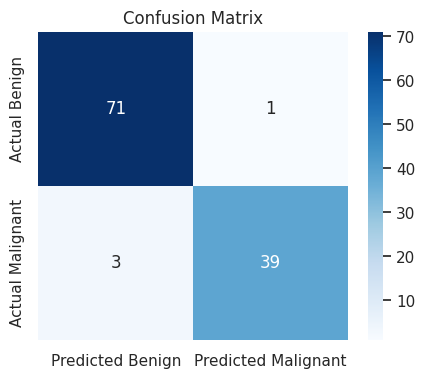

In [34]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted Benign", "Predicted Malignant"],
            yticklabels=["Actual Benign", "Actual Malignant"])
plt.title("Confusion Matrix")
plt.show()

### Interpretation

Accuracy gives a general overview of model performance, but it is not sufficient on its own.

In medical classification, precision and recall are especially important:
- **Precision** answers: when the model predicts malignancy, how often is it correct?
- **Recall** answers: how many malignant tumors does the model successfully detect?

Recall is particularly important in this context because missing a malignant tumor can have serious consequences.

In [ ]:
# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Interpretation

The ROC curve shows how well the model separates benign and malignant tumors across all possible classification thresholds.

A curve that rises quickly toward the top-left corner indicates strong discriminatory power. The AUC summarizes this performance:
- **AUC = 0.5** means no real discrimination
- **AUC closer to 1.0** indicates excellent separation

In [35]:
# Coefficients / predictive power
coefficients = pd.DataFrame({
    "feature": data.feature_names,
    "coefficient": model.coef_[0],
    "abs_coefficient": np.abs(model.coef_[0])
}).sort_values("abs_coefficient", ascending=False)

coefficients.head(15)


,feature,coefficient,abs_coefficient
21,worst texture,1.434093,1.434093
10,radius error,1.233325,1.233325
28,worst symmetry,1.061264,1.061264
7,mean concave points,0.952813,0.952813
26,worst concavity,0.911406,0.911406
13,area error,0.909029,0.909029
15,compactness error,-0.906925,0.906925
23,worst area,0.900477,0.900477
20,worst radius,0.896968,0.896968
6,mean concavity,0.782298,0.782298


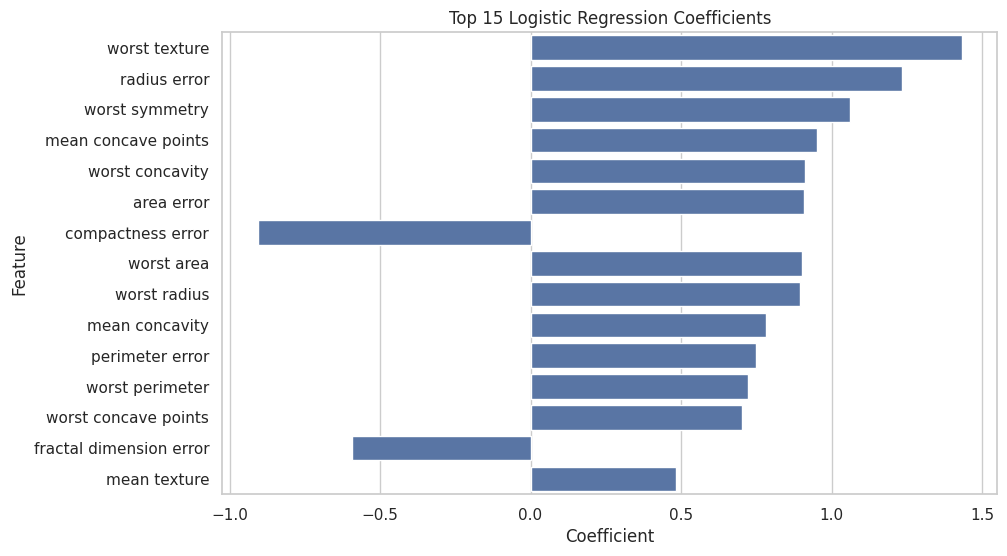

In [36]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=coefficients.head(15),
    x="coefficient",
    y="feature"
)
plt.title("Top 15 Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

### Interpretation

The magnitude of the logistic regression coefficients provides a rough indication of predictive importance after scaling.

Features with large absolute coefficients contribute more strongly to the model’s decision boundary. However, because many predictors are correlated, coefficient interpretation should be made with caution.

In [40]:
# Predict probabilities (wichtig für ROC!)
y_prob = model.predict_proba(X_test)[:, 1]

# ROC Curve berechnen
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# DataFrame erstellen
threshold_df = pd.DataFrame({
    "threshold": thresholds,
    "tpr_recall": tpr,
    "fpr": fpr
})

threshold_df.head(10)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


,threshold,tpr_recall,fpr
0,inf,0.0,0.0
1,1.0,1.0,1.0


## 7. Error Analysis

False positives and false negatives matter differently in a medical context.

- **False positive**: a benign tumor is predicted as malignant
- **False negative**: a malignant tumor is predicted as benign

False negatives are generally more serious because they represent missed malignant cases.

In [41]:
tn, fp, fn, tp = cm.ravel()

print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")


True Negatives:  71
False Positives: 1
False Negatives: 3
True Positives:  39


### Interpretation

The confusion matrix helps evaluate what kind of mistakes the model makes.

In this problem, reducing false negatives is especially important. Depending on the application, it may be preferable to lower the decision threshold in order to improve recall, even at the cost of more false positives.

## 8. Conclusion

This analysis explored the Breast Cancer Wisconsin dataset from both an exploratory and predictive perspective.

### Main findings
- The dataset contains both benign and malignant tumors, with a moderate class imbalance.
- Radius, area, and related geometric features show strong differences between classes.
- Larger tumors tend to have a higher malignancy rate.
- Several predictors are strongly correlated, especially radius, perimeter, and area features.
- Logistic regression performs well as a baseline classifier.
- The ROC curve and AUC confirm that the model has strong discriminatory ability.
- In a medical context, recall is especially important because false negatives are more critical than false positives.

### Final remark
This project shows how exploratory analysis and machine learning can work together to understand disease-related patterns and support classification tasks in a transparent and interpretable way.